# Knee Injuries Classification Project
## MRNet Classifier Notebook --> TRAINING A Multi-View 2D-CNN with a Transformer Head

- Use a shared ResNet-18 for all three views.
- Concatenate the features from Axial, Coronal, and Sagittal views into one long vector.
- Use a Transformer Encoder layer (Self-Attention) to let the model decide which slices and which views are the most important for the diagnosis.
- Using a weighted loss --> if acl tears are 4x as less likely as non-acl tears, penalize missing acl tears 4x as much

### Data source:
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [1]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import sys
import os
import zipfile
import shutil

### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code.

In [2]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder

Mounted at /content/drive


In [ ]:



# # since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
# shared_folder_path = '/content/drive/MyDrive/MLII Final/Data/mrnet_images'

# # DESTINATION: The local, ultra-fast Colab cloud SSD storage
# local_zip_path = '/content/drive/MyDrive/MLII Final/Data/mrnet_images.zip'

# print("Starting optimized compression onto local cloud SSD...")

# # 2. Zip from Drive directly to the local cloud SSD
# !zip -rq "{local_zip_path}" "{shared_folder_path}"

# print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# # # 3. Copy the single large zip back to Google Drive in one efficient burst
# # !cp "{local_zip_path}" "/content/drive/MyDrive/"

# print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

### Loading data into colab SSD
When we already have your zip folder, we can start from here to git the data unziped inside the colab SSD.

In [3]:
# 1. Mount persistent storage
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls "/content/drive/MyDrive/MLII Final"

 best_mri_transformer.pth
 best_mri_transformer_v2.pth
 best_mri_transformer_v3.pth
 best_mrnet_stage3.pth
 best_mrnet_stage4.pth
 Data
'Machine learning Slides 2.pptx'
'Machine learning Slides.pptx'
'MRNet Project_ Cloud Environment Architecture and Workflow Guide.pdf'
 Proposal.gdoc
 stage3_results.png
 training_results_v2.png


In [5]:
import os
if os.path.exists('/content/mrnet_images.zip'):
    os.remove('/content/mrnet_images.zip')
    print("Corrupted local zip removed. Please run your main cell again.")

In [6]:
zip_source = '/content/drive/MyDrive/MLII Final/Data/mrnet_images.zip'

# 2. Point to the LOCAL Colab environment for the copy destination
zip_local = '/content/mrnet_images.zip'

# 3. Where the final unzipped images should live
final_image_dir = '/content/mrnet_images'
extract_to = '/content/'

# ==========================================
# RUN EXTRACTION SEQUENCE
# ==========================================
if not os.path.exists(final_image_dir):

    # Safety Check: Verify the zip file actually exists on Drive
    if not os.path.exists(zip_source):
        raise FileNotFoundError(f"Could not find your zip file at: {zip_source}. Double check the file name extension!")

    # Step A: Copy the zip from Drive to local SSD if it's missing
    if not os.path.exists(zip_local):
        print("Transferring optimized archive from Drive to local cloud SSD...")
        shutil.copy(zip_source, zip_local)
        print("Transfer complete! Starting extraction...")

    # Step B: Unzip with the visible progress counter
    print("Opening zip archive securely...")
    with zipfile.ZipFile(zip_local, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        print(f"Total files to extract: {total_files}")

        # Discover the top-level directory name inside the zip file dynamically
        # (Usually 'MRNet-v1.0/' or 'mrnet/')
        top_level_internal_dir = files[0].split('/')[0]

        for index, file in enumerate(files):
            zip_ref.extract(file, extract_to)
            if index % 500 == 0 and index > 0:
                print(f"-> Extracted {index}/{total_files} files... ({int(index/total_files*100)}%)")

    print("Unpacking complete!")

    # Step C: Fix the path nesting structure automatically
    # Dynamically maps whatever folder name was inside the zip straight to '/content/mrnet_images'
    internal_extracted_path = os.path.join('/content', top_level_internal_dir)

    if os.path.exists(internal_extracted_path):
        print(f"Correcting zip path nesting structure: Renaming {internal_extracted_path} to {final_image_dir}...")
        os.rename(internal_extracted_path, final_image_dir)

    # Step D: Clean up the local copy of the zip file to save SSD space
    if os.path.exists(zip_local):
        os.remove(zip_local)
        print("Temporary local zip cleared from scratch disk.")

    print("Environment Setup Perfected!")
else:
    print("Data already unpacked and ready on local SSD.")

Transferring optimized archive from Drive to local cloud SSD...


KeyboardInterrupt: 

### Importing .py file

In [ ]:
import importlib
# 1. Clone the repository if it doesn't exist on the cloud machine yet
repo_path = '/content/CNN_ClassModeling'

if not os.path.exists(repo_path):
    print("Cloning the code repository from GitHub...")
    !git clone https://github.com/AbdulAlbaqami/Knee_Injuries_Classification_Model_MRI_Images.git {repo_path}
else:
    print("Repository already exists. Pulling latest updates...")
    !cd {repo_path} && git pull

# 2. Inject the repository path into Python's system search path
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 3. Safe Module Import / Reload Logic
import loading_data as ld
# If teammates update the file and you pull it, this line forces Python to update its cache
importlib.reload(ld)

print("Successfully imported loading_data.py module!")

Cloning the code repository from GitHub...
Cloning into '/content/CNN_ClassModeling'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 27 (delta 8), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 535.86 KiB | 17.29 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Successfully imported loading_data.py module!


In [ ]:
import numpy as np

# Load a single case
sample_volume = np.load('/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/axial/0228.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (24, 256, 256)


In [ ]:
ls "/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files"

axial/  coronal/  sagittal/


# Neural Network

In [8]:
import os, cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, auc as sk_auc

# ── Paths ──────────────────────────────────────────────────────────
BASE_DIR      = '/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images'
MASTER_CSV    = '/content/drive/MyDrive/MLII Final/Data/unified_labels.csv'
SAVE_PATH     = '/content/drive/MyDrive/MLII Final/best_mrnet_stage4.pth'
PRETRAIN_PATH = '/content/drive/MyDrive/MLII Final/stage4_contrastive_backbone.pth'

# ── Hyper-parameters ───────────────────────────────────────────────
BATCH_SIZE         = 2
ACCUMULATION_STEPS = 4          # effective batch = 8
EPOCHS             = 20
MAX_SLICES         = 40
TOP_K_SLICES       = 20         # slices kept per view after pre-filtering - LEGACY - thie doesnt do anything
D_FUSION           = 512        # fusion MLP hidden dim
FOCAL_GAMMA        = 2.0
LR                 = 3e-4
WEIGHT_DECAY       = 1e-2
FREEZE_EPOCHS      = 10         # unfreeze at ep20/30 (~LR 4e-6) — same late-unfreeze strategy scaled to 30 epochs

# ── Dual Attention ──────────────────────────────────────────────────
ATTN_REDUCTION  = 16            # SE channel reduction ratio
SPATIAL_KERNEL  = 7             # spatial attention conv kernel

# ── Contrastive Pretraining (optional) ─────────────────────────────
RUN_PRETRAIN       = False      # ← set True to enable
PRETRAIN_EPOCHS    = 10
PRETRAIN_LR        = 1e-3
PRETRAIN_BATCH     = 8
CONTRASTIVE_DIM    = 128
CONTRASTIVE_TEMP   = 0.07

# ── Class imbalance weights ─────────────────────────────────────────
ACL_POS_WEIGHT = 4.07           # 757/186
MEN_POS_WEIGHT = 1.83           # 610/333
ABN_POS_WEIGHT = 1.0            # 80% positive — no boost needed; 2.5 caused pred_mean collapse to 0.85

SUBSET_RATIO = 1              # full dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device       : {DEVICE}")
print(f"Top-K slices : {TOP_K_SLICES}/{MAX_SLICES} per view after pre-filter")
print(f"D_FUSION     : {D_FUSION}   Subset: {int(SUBSET_RATIO*100)}%")
print(f"Contrastive pretraining: {'ENABLED' if RUN_PRETRAIN else 'DISABLED (set RUN_PRETRAIN=True to enable)'}")


Device       : cuda
Top-K slices : 20/40 per view after pre-filter
D_FUSION     : 512   Subset: 100%
Contrastive pretraining: DISABLED (set RUN_PRETRAIN=True to enable)


In [9]:
class MRNetDataset(Dataset):
    """
    Returns per-sample:
      ax, cor, sag       : (MAX_SLICES, 3, 224, 224)  float tensors
      mask_ax/cor/sag    : (MAX_SLICES,)  bool — True = PADDING for THAT view
      label              : (3,)           [acl, meniscus, abnormal]

    Each view carries its OWN padding mask so that the model can use every
    real slice in each series independently.  The old union-mask threw away
    valid slices whenever one view was shorter than the others.
    """
    SPLIT_SUBDIR = {'train': '', 'valid': 'valid_files'}

    def __init__(self, base_dir, csv_path, split='train',
                 subset_ratio=1.0, max_slices=40, augment=False):
        self.base_dir   = base_dir
        self.split      = split
        self.max_slices = max_slices
        self.subdir     = self.SPLIT_SUBDIR[split]

        df = pd.read_csv(csv_path)
        self.labels = df[df['split'] == split].copy()
        self.labels['exam_id'] = self.labels['exam_id'].astype(str).str.zfill(4)

        if subset_ratio < 1.0 and split == 'train':
            self.labels = self.labels.sample(
                frac=subset_ratio, random_state=42).reset_index(drop=True)

        aug_steps = [
            T.ToPILImage(), T.Resize((224, 224)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
        ] if augment else [T.ToPILImage(), T.Resize((224, 224))]

        self.transform = T.Compose(aug_steps + [
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
        ])

    def _build_path(self, view, pid):
        if self.subdir:
            return os.path.join(self.base_dir, self.subdir, view, f'{pid}.npy')
        return os.path.join(self.base_dir, view, f'{pid}.npy')

    def _load_volume(self, path):
        vol = np.load(path).astype(np.float32)
        v_min, v_max = vol.min(), vol.max()
        if v_max - v_min > 1e-6:
            vol = (vol - v_min) / (v_max - v_min) * 255.0
        vol = vol.astype(np.uint8)

        s, h, w  = vol.shape
        n_real   = min(s, self.max_slices)   # actual slice count before padding

        # Centre-crop if too long
        if s > self.max_slices:
            start = (s - self.max_slices) // 2
            vol   = vol[start : start + self.max_slices]
            s     = self.max_slices

        slices = []
        for i in range(s):
            rgb = np.stack([vol[i]] * 3, axis=-1)
            slices.append(self.transform(rgb))

        # Zero-pad to MAX_SLICES
        if s < self.max_slices:
            pad_slice = torch.zeros_like(slices[0])
            slices   += [pad_slice] * (self.max_slices - s)

        # Padding mask: True = padding token (to be IGNORED by Transformer)
        mask = torch.zeros(self.max_slices, dtype=torch.bool)
        mask[n_real:] = True

        return torch.stack(slices), mask   # (S, 3, H, W),  (S,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]
        pid = row['exam_id']

        ax,  mask_ax  = self._load_volume(self._build_path('axial',    pid))
        cor, mask_cor = self._load_volume(self._build_path('coronal',  pid))
        sag, mask_sag = self._load_volume(self._build_path('sagittal', pid))

        # Per-view masking: each view keeps its own mask so no real slices
        # are discarded because a *different* view happens to be shorter.
        # The model's _encode_view receives the correct mask for each view.
        lbl = torch.tensor(
            [row['acl'], row['meniscus'], row['abnormal']],
            dtype=torch.float32)

        return ax, cor, sag, mask_ax, mask_cor, mask_sag, lbl


In [10]:
train_dataset = MRNetDataset(BASE_DIR, MASTER_CSV, split='train',
                              max_slices=MAX_SLICES, augment=True,
                              subset_ratio=SUBSET_RATIO)
valid_dataset = MRNetDataset(BASE_DIR, MASTER_CSV, split='valid',
                              max_slices=MAX_SLICES, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Valid samples : {len(valid_dataset)}")

# ── Path check ────────────────────────────────────────────────────
def check_paths(dataset, label=''):
    row = dataset.labels.iloc[0]
    pid = row['exam_id']
    for view in ['axial', 'coronal', 'sagittal']:
        p = dataset._build_path(view, pid)
        print(f"  {'✓' if os.path.exists(p) else '✗ MISSING'} [{label}] {p}")

check_paths(train_dataset, 'train')
check_paths(valid_dataset, 'valid')

# Sanity check tensor shapes + mask
ax, cor, sag, mask_ax, mask_cor, mask_sag, lbl = train_dataset[0]
print(f"\nAxial    : {ax.shape}   real slices: {(~mask_ax).sum().item()}/{MAX_SLICES}")
print(f"Coronal  : {cor.shape}  real slices: {(~mask_cor).sum().item()}/{MAX_SLICES}")
print(f"Sagittal : {sag.shape}  real slices: {(~mask_sag).sum().item()}/{MAX_SLICES}")
print(f"Labels : {lbl}")


Train samples : 943
Valid samples : 119
  ✗ MISSING [train] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/axial/1027.npy
  ✗ MISSING [train] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/coronal/1027.npy
  ✗ MISSING [train] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/sagittal/1027.npy
  ✗ MISSING [valid] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files/axial/1139.npy
  ✗ MISSING [valid] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files/coronal/1139.npy
  ✗ MISSING [valid] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files/sagittal/1139.npy


FileNotFoundError: [Errno 2] No such file or directory: '/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/axial/1027.npy'

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 4a · Dual Attention Module (CBAM-style)
# ─────────────────────────────────────────────────────────────────────────────

class ChannelAttention(nn.Module):
    """SE-style: avg-pool + max-pool both through shared MLP, then sigmoid-scale."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )

    def forward(self, x):
        avg   = self.fc(self.avg_pool(x).flatten(1))
        mx    = self.fc(self.max_pool(x).flatten(1))
        scale = torch.sigmoid(avg + mx).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class SpatialAttention(nn.Module):
    """CBAM spatial: channel avg+max → 2-ch conv → sigmoid map."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)

    def forward(self, x):
        avg_map = x.mean(dim=1, keepdim=True)
        max_map = x.max( dim=1, keepdim=True).values
        scale   = torch.sigmoid(self.conv(torch.cat([avg_map, max_map], dim=1)))
        return x * scale


class DualAttention(nn.Module):
    """Channel attention → Spatial attention (sequential CBAM order)."""
    def __init__(self, channels: int,
                 reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.spatial(self.channel(x))


# ─────────────────────────────────────────────────────────────────────────────
# 4b · Soft Slice Attention Pooling  (replaces hard top-K selection)
# ─────────────────────────────────────────────────────────────────────────────

class SoftSliceAttention(nn.Module):
    """
    Differentiable soft-attention pooling over slices.

    A lightweight CNN scorer produces a scalar logit per slice.
    Padding positions are masked to -inf before softmax so they
    receive zero weight and never contribute to the pooled embedding.
    The resulting attention weights are fully differentiable, giving
    clean gradients back to the scorer throughout training — unlike
    hard top-K which has zero gradient for dropped slices.

    Architecture: identical 32/64/128-channel CNN as the old SliceScorer,
    so the parameter count is unchanged.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32,  3, stride=2, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 128,3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(128, 1)

    def score(self, x):
        """x: (N, 3, H, W) → scalar logit per slice (N,)."""
        return self.head(self.net(x).flatten(1)).squeeze(-1)

    def forward(self, vol, pad_mask):
        """
        vol      : (B, S, 3, H, W)
        pad_mask : (B, S)  True = padding (ignored)
        Returns  : (B, 512) soft-attention-weighted mean of slice features
                   computed AFTER backbone+attention — caller passes
                   slice features directly (see _encode_view).

        Note: this method is not called directly; _encode_view calls
        self.soft_attn.score() then applies softmax + weighted sum itself
        so the backbone only runs once per slice.
        """
        B, S, C, H, W = vol.shape
        flat   = vol.view(B * S, C, H, W)
        logits = self.score(flat).view(B, S)              # (B, S)
        logits = logits.masked_fill(pad_mask, float('-inf'))
        return torch.softmax(logits, dim=1)               # (B, S) weights


# ─────────────────────────────────────────────────────────────────────────────
# 4c · Main Model — No Transformer, Soft-Attention Fusion
# ─────────────────────────────────────────────────────────────────────────────

class MRNetDualAttn(nn.Module):
    """
    Stage 4 architecture (transformer-free):

    Per view (axial / coronal / sagittal):
      1. All MAX_SLICES slices are run through the shared ResNet-18 backbone.
      2. DualAttention applied on the last conv feature map (512-ch).
      3. Global avg pool → 512-d feature per slice.
      4. SoftSliceAttention scores every slice and produces softmax weights
         (padding positions receive -inf → 0 weight).  Weighted sum gives
         the 512-d view embedding.  Fully differentiable — no gradient
         blocking from hard top-K selection.

    Fusion:
      5. Concat the three view embeddings → 1536-d.
      6. Fusion MLP (1536 → D_FUSION → 256) shared across tasks.
      7. Three lightweight task heads (256 → 1).
         Abnormality head receives its own deeper MLP (not detached —
         detach was suppressing the abnormality gradient entirely).

    Changes vs previous version:
      • Hard top-K slice selection replaced by soft-attention pooling.
        Gradients now flow to the scorer from every slice, not just the
        top-K survivors.
      • Per-view padding masks: each view uses its own mask, so no real
        slices are discarded because a sibling view is shorter.
      • Two-phase cosine schedule: frozen phase + warm restart on unfreeze.
    """

    def __init__(self, top_k: int = 10, d_fusion: int = 512,
                 reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()
        # top_k kept as parameter for API compatibility but no longer used
        # for hard selection — soft attention pools over all real slices.
        self.top_k = top_k

        # ── Soft slice attention pooling ──────────────────────────
        self.soft_attn = SoftSliceAttention()

        # ── Shared backbone (all layers except avgpool + fc) ──────
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone_layers = nn.ModuleList(list(resnet.children())[:-2])
        self.global_pool     = nn.AdaptiveAvgPool2d(1)

        # ── Dual attention on 512-ch last feature map ─────────────
        self.dual_attention = DualAttention(512, reduction, spatial_kernel)

        # ── Fusion MLP: 3 views × 512 → d_fusion → 256 ───────────
        self.fusion = nn.Sequential(
            nn.Linear(512 * 3, d_fusion),
            nn.LayerNorm(d_fusion),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(d_fusion, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        # ── Task heads ────────────────────────────────────────────
        # ACL + Meniscus: single linear (fused repr is already rich)
        self.head_acl = nn.Linear(256, 1)
        self.head_men = nn.Linear(256, 1)
        # Abnormality: deeper head — it's a global signal not captured by
        # the same features that localise ACL/meniscus tears
        self.head_abn = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    # ──────────────────────────────────────────────────────────────
    def _run_backbone(self, x):
        """x: (N, 3, H, W) → last conv feature map (N, 512, h, w)."""
        for layer in self.backbone_layers:
            x = layer(x)
        return x

    def _encode_view(self, vol, pad_mask):
        """
        vol      : (B, S, 3, H, W)
        pad_mask : (B, S)
        Returns  : (B, 512)  soft-attention-pooled view embedding
        """
        B, S, C, H, W = vol.shape
        flat = vol.view(B * S, C, H, W)

        # Step 1 — backbone on all slices
        feat_map = self._run_backbone(flat)       # (B*S, 512, h, w)

        # Step 2 — dual attention
        feat_map = self.dual_attention(feat_map)  # (B*S, 512, h, w)

        # Step 3 — global pool → per-slice feature vectors
        feat = self.global_pool(feat_map).view(B, S, 512)   # (B, S, 512)

        # Step 4 — soft attention weights from the scorer CNN
        # Scores are computed on the RAW input slices (no backbone),
        # keeping the scorer cheap and decoupled from feature learning.
        attn_w = self.soft_attn(vol, pad_mask)    # (B, S) softmax weights

        # Step 5 — weighted sum → view embedding
        # attn_w: (B, S)  feat: (B, S, 512)
        view_feat = (attn_w.unsqueeze(-1) * feat).sum(dim=1)  # (B, 512)
        return view_feat

    def forward(self, ax, cor, sag, mask_ax, mask_cor, mask_sag):
        """
        ax, cor, sag         : (B, S, 3, H, W)
        mask_ax/mask_cor/mask_sag : (B, S)  True = padding for THAT view

        Each view is encoded with its own padding mask so that real slices
        are never masked out because a different view is shorter.
        """
        f_ax  = self._encode_view(ax,  mask_ax)
        f_cor = self._encode_view(cor, mask_cor)
        f_sag = self._encode_view(sag, mask_sag)

        fused = self.fusion(torch.cat([f_ax, f_cor, f_sag], dim=1))  # (B, 256)

        acl = self.head_acl(fused)
        men = self.head_men(fused)
        abn = self.head_abn(fused)   # NOT detached — detach was killing abnormality gradient
        return acl, men, abn

    # ── Freeze / unfreeze helpers ──────────────────────────────────
    def freeze_bn(self):
        for m in self.backbone_layers.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                m.weight.requires_grad = False
                m.bias.requires_grad   = False

    def freeze_backbone(self):
        for p in self.backbone_layers.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone_layers.parameters():
            p.requires_grad = True

    def load_pretrained_weights(self, backbone_sd, attention_sd):
        """Transfer weights from optional contrastive pretraining checkpoint."""
        own_sd  = self.state_dict()
        new_sd  = {}
        loaded_bb, loaded_att = 0, 0
        for name, param in own_sd.items():
            if name.startswith('backbone_layers.'):
                key = name[len('backbone_layers.'):]
                if key in backbone_sd and backbone_sd[key].shape == param.shape:
                    new_sd[name] = backbone_sd[key]; loaded_bb += 1; continue
            if name.startswith('dual_attention.'):
                key = name[len('dual_attention.'):]
                if key in attention_sd and attention_sd[key].shape == param.shape:
                    new_sd[name] = attention_sd[key]; loaded_att += 1; continue
            new_sd[name] = param
        self.load_state_dict(new_sd, strict=False)
        print(f"  ✓ Loaded {loaded_bb} backbone + {loaded_att} attention params from contrastive checkpoint.")


In [12]:
# ── Only runs if RUN_PRETRAIN = True ──────────────────────────────
if RUN_PRETRAIN:

    class MRIContrastiveTransform:
        def __init__(self):
            self.aug = T.Compose([
                T.ToPILImage(), T.Resize((224, 224)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomApply([T.RandomRotation(15)], p=0.8),
                T.RandomApply([T.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
                T.ToTensor(),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
                T.RandomErasing(p=0.3, scale=(0.02,0.12)),
            ])
        def __call__(self, x):
            rgb = np.stack([x]*3, axis=-1)
            return self.aug(rgb), self.aug(rgb)

    class ContrastiveSliceDataset(Dataset):
        def __init__(self, base_dir, csv_path, max_slices=40, subset_ratio=1.0):
            self.transform = MRIContrastiveTransform()
            df = pd.read_csv(csv_path)
            df = df[df['split']=='train'].copy()
            df['exam_id'] = df['exam_id'].astype(str).str.zfill(4)
            if subset_ratio < 1.0:
                df = df.sample(frac=subset_ratio, random_state=42)
            self.index = []
            for _, row in df.iterrows():
                pid = row['exam_id']
                for v in ['axial','coronal','sagittal']:
                    p = os.path.join(base_dir, v, f'{pid}.npy')
                    if os.path.exists(p):
                        n = min(np.load(p, mmap_mode='r').shape[0], max_slices)
                        self.index.extend([(p, s) for s in range(n)])
        def __len__(self): return len(self.index)
        def __getitem__(self, idx):
            path, s = self.index[idx]
            vol = np.load(path).astype(np.float32)
            vmin,vmax = vol.min(),vol.max()
            slc = ((vol[s]-vmin)/(vmax-vmin+1e-6)*255).astype(np.uint8)
            return self.transform(slc)

    class NTXentLoss(nn.Module):
        def __init__(self, temperature=0.07):
            super().__init__(); self.T = temperature
        def forward(self, z1, z2):
            N = z1.size(0)
            z = torch.cat([z1,z2],0)
            sim = torch.mm(z,z.T)/self.T
            sim.fill_diagonal_(float('-inf'))
            labels = torch.cat([torch.arange(N,2*N),torch.arange(N)]).to(z.device)
            return F.cross_entropy(sim, labels)

    class ContrastiveWrapper(nn.Module):
        """Wraps the main model's backbone+attention for pretraining only."""
        def __init__(self, backbone_layers, dual_attention, proj_dim=128):
            super().__init__()
            self.backbone_layers = backbone_layers
            self.dual_attention  = dual_attention
            self.global_pool     = nn.AdaptiveAvgPool2d(1)
            self.projector = nn.Sequential(
                nn.Linear(512, 256, bias=False), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
                nn.Linear(256, proj_dim, bias=False), nn.BatchNorm1d(proj_dim, affine=False),
            )
        def _encode(self, x):
            for layer in self.backbone_layers: x = layer(x)
            x = self.dual_attention(x)
            return self.global_pool(x).flatten(1)
        def forward(self, x1, x2):
            h1 = self._encode(x1); h2 = self._encode(x2)
            return F.normalize(self.projector(h1),1), F.normalize(self.projector(h2),1)

    print("\n═══ Contrastive Pretraining ═══")
    # Build a temporary wrapper around the model's own backbone + attention
    model_c = ContrastiveWrapper(
        model.backbone_layers, model.dual_attention, CONTRASTIVE_DIM
    ).to(DEVICE)

    ds_c = ContrastiveSliceDataset(BASE_DIR, MASTER_CSV,
                                    max_slices=MAX_SLICES, subset_ratio=SUBSET_RATIO)
    ld_c = DataLoader(ds_c, batch_size=PRETRAIN_BATCH, shuffle=True,
                      num_workers=0, pin_memory=True, drop_last=True)
    loss_c  = NTXentLoss(CONTRASTIVE_TEMP).to(DEVICE)
    opt_c   = optim.AdamW(model_c.parameters(), lr=PRETRAIN_LR, weight_decay=1e-4)
    sched_c = optim.lr_scheduler.CosineAnnealingLR(opt_c, T_max=PRETRAIN_EPOCHS, eta_min=1e-5)
    scaler_c = torch.amp.GradScaler('cuda')

    for ep in range(PRETRAIN_EPOCHS):
        model_c.train(); total = 0.0
        for v1, v2 in tqdm(ld_c, desc=f"  Pretrain {ep+1}/{PRETRAIN_EPOCHS}", leave=False):
            v1,v2 = v1.to(DEVICE),v2.to(DEVICE)
            with torch.amp.autocast('cuda'):
                z1,z2 = model_c(v1,v2); l = loss_c(z1,z2)
            scaler_c.scale(l).backward()
            scaler_c.unscale_(opt_c)
            torch.nn.utils.clip_grad_norm_(model_c.parameters(),1.0)
            scaler_c.step(opt_c); scaler_c.update(); opt_c.zero_grad()
            total += l.item()
        sched_c.step()
        print(f"  Ep {ep+1:02d} NT-Xent: {total/len(ld_c):.4f}  LR: {sched_c.get_last_lr()[0]:.2e}")

    torch.save({'backbone': {k:v for k,v in model.backbone_layers.state_dict().items()},
                'attention': {k:v for k,v in model.dual_attention.state_dict().items()}},
               PRETRAIN_PATH)
    print(f"  ✓ Pretrained weights saved → {PRETRAIN_PATH}")
    del model_c, ds_c, ld_c, loss_c, opt_c, sched_c, scaler_c

elif os.path.exists(PRETRAIN_PATH):
    print(f"Loading existing contrastive checkpoint: {PRETRAIN_PATH}")
    ckpt_c = torch.load(PRETRAIN_PATH, map_location=DEVICE)
    model.load_pretrained_weights(ckpt_c['backbone'], ckpt_c['attention'])

else:
    print("Contrastive pretraining skipped — using ImageNet weights.")


Contrastive pretraining skipped — using ImageNet weights.


In [13]:
class FocalMultiTaskLoss(nn.Module):
    """
    Focal Loss per task with class-imbalance pos_weight.
    Task multipliers scaled inversely to positive rate:
      ACL (19.7% pos)  → 5.0
      Meniscus (35.3%) → 2.8
      Abnormality (80%) → 3.5  (raised — global signal needs stronger gradient)
    """
    TASK_MULTIPLIERS = [5.0, 3, 3]  # raised abn: was 1.0, now matches its difficulty

    def __init__(self, pos_weights: list, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma
        self.register_buffer('pos_weights',
                              torch.tensor(pos_weights, dtype=torch.float32))

    def forward(self, preds, targets):
        total_loss = 0.0
        loss_parts = []
        for i in range(3):
            logit  = preds[i].squeeze(-1)
            target = targets[:, i].float()
            bce = nn.functional.binary_cross_entropy_with_logits(
                logit, target,
                pos_weight=self.pos_weights[i],
                reduction='none'
            )
            p_t    = torch.exp(-bce)
            f_loss = ((1.0 - p_t) ** self.gamma * bce).mean()
            total_loss = total_loss + self.TASK_MULTIPLIERS[i] * f_loss
            loss_parts.append(f_loss.item())
        return total_loss, loss_parts


In [14]:
DEVICE

device(type='cuda')

In [ ]:
model = MRNetDualAttn(
    top_k          = TOP_K_SLICES,
    d_fusion       = D_FUSION,
    reduction      = ATTN_REDUCTION,
    spatial_kernel = SPATIAL_KERNEL,
).to(DEVICE)

criterion = FocalMultiTaskLoss(
    pos_weights=[ACL_POS_WEIGHT, MEN_POS_WEIGHT, ABN_POS_WEIGHT],
    gamma=FOCAL_GAMMA,
).to(DEVICE)

# Three param groups:
#   backbone  → LR/10 (fine-tune carefully)
#   attention + scorer → LR/3 (new modules, but small)
#   fusion + heads     → LR   (fully new)
optimizer = optim.AdamW([
    {'params': model.backbone_layers.parameters(),
     'lr': LR/10, 'weight_decay': WEIGHT_DECAY},
    {'params': list(model.dual_attention.parameters()) +
               list(model.soft_attn.parameters()),
     'lr': LR/3, 'weight_decay': WEIGHT_DECAY},
    {'params': list(model.fusion.parameters()) +
               list(model.head_acl.parameters()) +
               list(model.head_men.parameters()) +
               list(model.head_abn.parameters()),
     'lr': LR, 'weight_decay': WEIGHT_DECAY},
], lr=LR)

# ── Two-phase cosine schedule ─────────────────────────────────────────────
# Phase 1 (frozen epochs): cosine decay from LR → eta_min over FREEZE_EPOCHS.
# Phase 2 (unfrozen epochs): fresh warm restart from LR_UNFREEZE → eta_min
#   over the remaining (EPOCHS - FREEZE_EPOCHS) epochs.
# The restart is triggered manually in the training loop at epoch==FREEZE_EPOCHS.
LR_UNFREEZE    = LR         # restart head LR (backbone group stays at /10)
ETA_MIN_FROZEN = 1e-5       # floor for phase 1
ETA_MIN_UNFROZ = 1e-6       # tighter floor for phase 2 (backbone now active)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FREEZE_EPOCHS, eta_min=ETA_MIN_FROZEN
)
scaler    = torch.amp.GradScaler('cuda')

model.freeze_backbone()

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_p:,}")
print(f"Trainable params: {trainable_p:,}  (backbone frozen)")
print(f"Backbone unfreezes at epoch {FREEZE_EPOCHS}")

RESUME = True
start_epoch  = 0
best_val_auc = 0.0

if RESUME and os.path.exists(SAVE_PATH):
    ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch  = ckpt['epoch'] + 1
    best_val_auc = ckpt['auc']
    print(f"Resumed from epoch {start_epoch}  best AUC={best_val_auc:.4f}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Total params    : 12,256,806
Trainable params: 1,080,294  (backbone frozen)
Backbone unfreezes at epoch 10
Resumed from epoch 14  best AUC=0.8779


In [ ]:
def get_accuracy(logits, targets):
    return ((torch.sigmoid(logits) > 0.5).float() == targets).float().mean().item()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acl_acc': [], 'train_men_acc': [], 'train_abn_acc': [],
    'val_acl_acc':   [], 'val_men_acc':   [], 'val_abn_acc':   [],
    'val_acl_auc':   [], 'val_men_auc':   [], 'val_abn_auc':   [],
    'lr': [],
}
task_keys  = ['acl', 'men', 'abn']
task_names = ['ACL', 'Meniscus', 'Abnormality']

for epoch in range(start_epoch, EPOCHS):

    # ── Backbone freeze / unfreeze ────────────────────────────────
    if epoch == 0:
        model.freeze_backbone()
    elif epoch == FREEZE_EPOCHS:
        model.unfreeze_backbone()
        # Phase 2: reset LRs and start a fresh cosine schedule for the
        # remaining (EPOCHS - FREEZE_EPOCHS) epochs.
        for pg in optimizer.param_groups:
            pg['lr'] = pg.get('initial_lr', LR)   # restore to construction LR
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(EPOCHS - FREEZE_EPOCHS, 1),
            eta_min=ETA_MIN_UNFROZ,
        )
        print(f">>> Backbone UNFROZEN at epoch {epoch} — Phase-2 cosine restart "
              f"(backbone LR={LR/10:.1e}, head LR={LR:.1e})")

    # ── TRAIN ─────────────────────────────────────────────────────
    model.train()
    model.freeze_bn()

    epoch_train_loss = 0.0
    t_accs = {j: [] for j in range(3)}
    optimizer.zero_grad()

    train_bar = tqdm(train_loader, desc=f"Ep {epoch+1}/{EPOCHS} [Train]",
                     leave=False)
    for step, (ax, cor, sag, mask_ax, mask_cor, mask_sag, labels) in enumerate(train_bar):
        ax, cor, sag = ax.to(DEVICE), cor.to(DEVICE), sag.to(DEVICE)
        mask_ax      = mask_ax.to(DEVICE)
        mask_cor     = mask_cor.to(DEVICE)
        mask_sag     = mask_sag.to(DEVICE)
        labels       = labels.to(DEVICE)

        with torch.amp.autocast('cuda'):
            preds = model(ax, cor, sag, mask_ax, mask_cor, mask_sag)
            loss, loss_parts = criterion(preds, labels)
            scaled_loss = loss / ACCUMULATION_STEPS

        scaler.scale(scaled_loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            # Per-task gradient surgery before global clip
            for head in [model.head_acl, model.head_men, model.head_abn]:
                head_params = [p for p in head.parameters() if p.grad is not None]
                if head_params:
                    torch.nn.utils.clip_grad_norm_(head_params, max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        epoch_train_loss += loss.item()
        for j in range(3):
            t_accs[j].append(get_accuracy(preds[j].squeeze(-1), labels[:, j]))

        train_bar.set_postfix(loss=f"{loss.item():.3f}",
                              acl=f"{loss_parts[0]:.3f}",
                              men=f"{loss_parts[1]:.3f}",
                              abn=f"{loss_parts[2]:.3f}")

    # Flush remaining gradients
    if len(train_loader) % ACCUMULATION_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]   # head LR (backbone is /10)

    # ── VALIDATE ──────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    v_accs        = {j: [] for j in range(3)}
    all_val_preds = [[] for _ in range(3)]
    all_val_true  = [[] for _ in range(3)]

    with torch.no_grad():
        for ax, cor, sag, mask_ax, mask_cor, mask_sag, labels in tqdm(
                valid_loader, desc=f"Ep {epoch+1}/{EPOCHS} [Val]", leave=False):
            ax, cor, sag = ax.to(DEVICE), cor.to(DEVICE), sag.to(DEVICE)
            mask_ax      = mask_ax.to(DEVICE)
            mask_cor     = mask_cor.to(DEVICE)
            mask_sag     = mask_sag.to(DEVICE)
            labels       = labels.to(DEVICE)

            preds  = model(ax, cor, sag, mask_ax, mask_cor, mask_sag)
            v_loss, _ = criterion(preds, labels)
            epoch_val_loss += v_loss.item()

            for j in range(3):
                logit = preds[j].squeeze(-1)
                v_accs[j].append(get_accuracy(logit, labels[:, j]))
                probs = torch.sigmoid(logit).cpu().numpy().flatten().tolist()
                all_val_preds[j].extend(probs)
                all_val_true[j].extend(labels[:, j].cpu().numpy().flatten().tolist())

    # ── Metrics ───────────────────────────────────────────────────
    history['train_loss'].append(epoch_train_loss / len(train_loader))
    history['val_loss'].append(epoch_val_loss   / len(valid_loader))
    history['lr'].append(current_lr)

    current_aucs = []
    for j, key in enumerate(task_keys):
        history[f'train_{key}_acc'].append(np.mean(t_accs[j]))
        history[f'val_{key}_acc'].append(np.mean(v_accs[j]))
        auc_val = roc_auc_score(all_val_true[j], all_val_preds[j])
        history[f'val_{key}_auc'].append(auc_val)
        current_aucs.append(auc_val)

    avg_auc = float(np.mean(current_aucs))

    # ── Print ─────────────────────────────────────────────────────
    frozen_str = 'frozen' if epoch < FREEZE_EPOCHS else 'unfrozen'
    print(f"\n── Epoch {epoch+1:02d}/{EPOCHS} ── "
          f"LR(head)={current_lr:.2e}  LR(backbone)={current_lr/10:.2e}  "
          f"backbone={frozen_str}")
    print(f"  Loss : train={history['train_loss'][-1]:.4f}  "
          f"val={history['val_loss'][-1]:.4f}")
    for j, (key, name) in enumerate(zip(task_keys, task_names)):
        probs = np.array(all_val_preds[j])
        print(f"  {name:11s}: acc={history[f'val_{key}_acc'][-1]:.3f}  "
              f"auc={current_aucs[j]:.3f}  "
              f"pred_mean={probs.mean():.3f}  pred_std={probs.std():.3f}")
    print(f"  Avg AUC : {avg_auc:.4f}  (best={best_val_auc:.4f})")

    if avg_auc > best_val_auc:
        best_val_auc = avg_auc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'auc'                 : avg_auc,
            'history'             : history,
        }, SAVE_PATH)
        print(f"  ⭐ New best → {SAVE_PATH}")

print(f"\nDone. Best Avg AUC = {best_val_auc:.4f}")


Ep 15/20 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Ep 15/20 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


── Epoch 15/20 ── LR(head)=1.00e-06  LR(backbone)=1.00e-07  backbone=unfrozen
  Loss : train=2.6569  val=3.7047
  ACL        : acc=0.850  auc=0.928  pred_mean=0.492  pred_std=0.311
  Meniscus   : acc=0.700  auc=0.788  pred_mean=0.561  pred_std=0.135
  Abnormality: acc=0.867  auc=0.917  pred_mean=0.799  pred_std=0.172
  Avg AUC : 0.8777  (best=0.8779)


Ep 16/20 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Ep 16/20 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]

...

Ep 19/20 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


── Epoch 19/20 ── LR(head)=2.72e-05  LR(backbone)=2.72e-06  backbone=unfrozen
  Loss : train=2.6973  val=4.7209
  ACL        : acc=0.850  auc=0.930  pred_mean=0.447  pred_std=0.302
  Meniscus   : acc=0.675  auc=0.770  pred_mean=0.600  pred_std=0.165
  Abnormality: acc=0.800  auc=0.916  pred_mean=0.869  pred_std=0.117
  Avg AUC : 0.8720  (best=0.8814)


Ep 20/20 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Ep 20/20 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


── Epoch 20/20 ── LR(head)=3.00e-05  LR(backbone)=3.00e-06  backbone=unfrozen
  Loss : train=2.9086  val=3.2883
  ACL        : acc=0.833  auc=0.927  pred_mean=0.556  pred_std=0.290
  Meniscus   : acc=0.675  auc=0.790  pred_mean=0.610  pred_std=0.160
  Abnormality: acc=0.817  auc=0.923  pred_mean=0.840  pred_std=0.141
  Avg AUC : 0.8800  (best=0.8814)

Done. Best Avg AUC = 0.8814


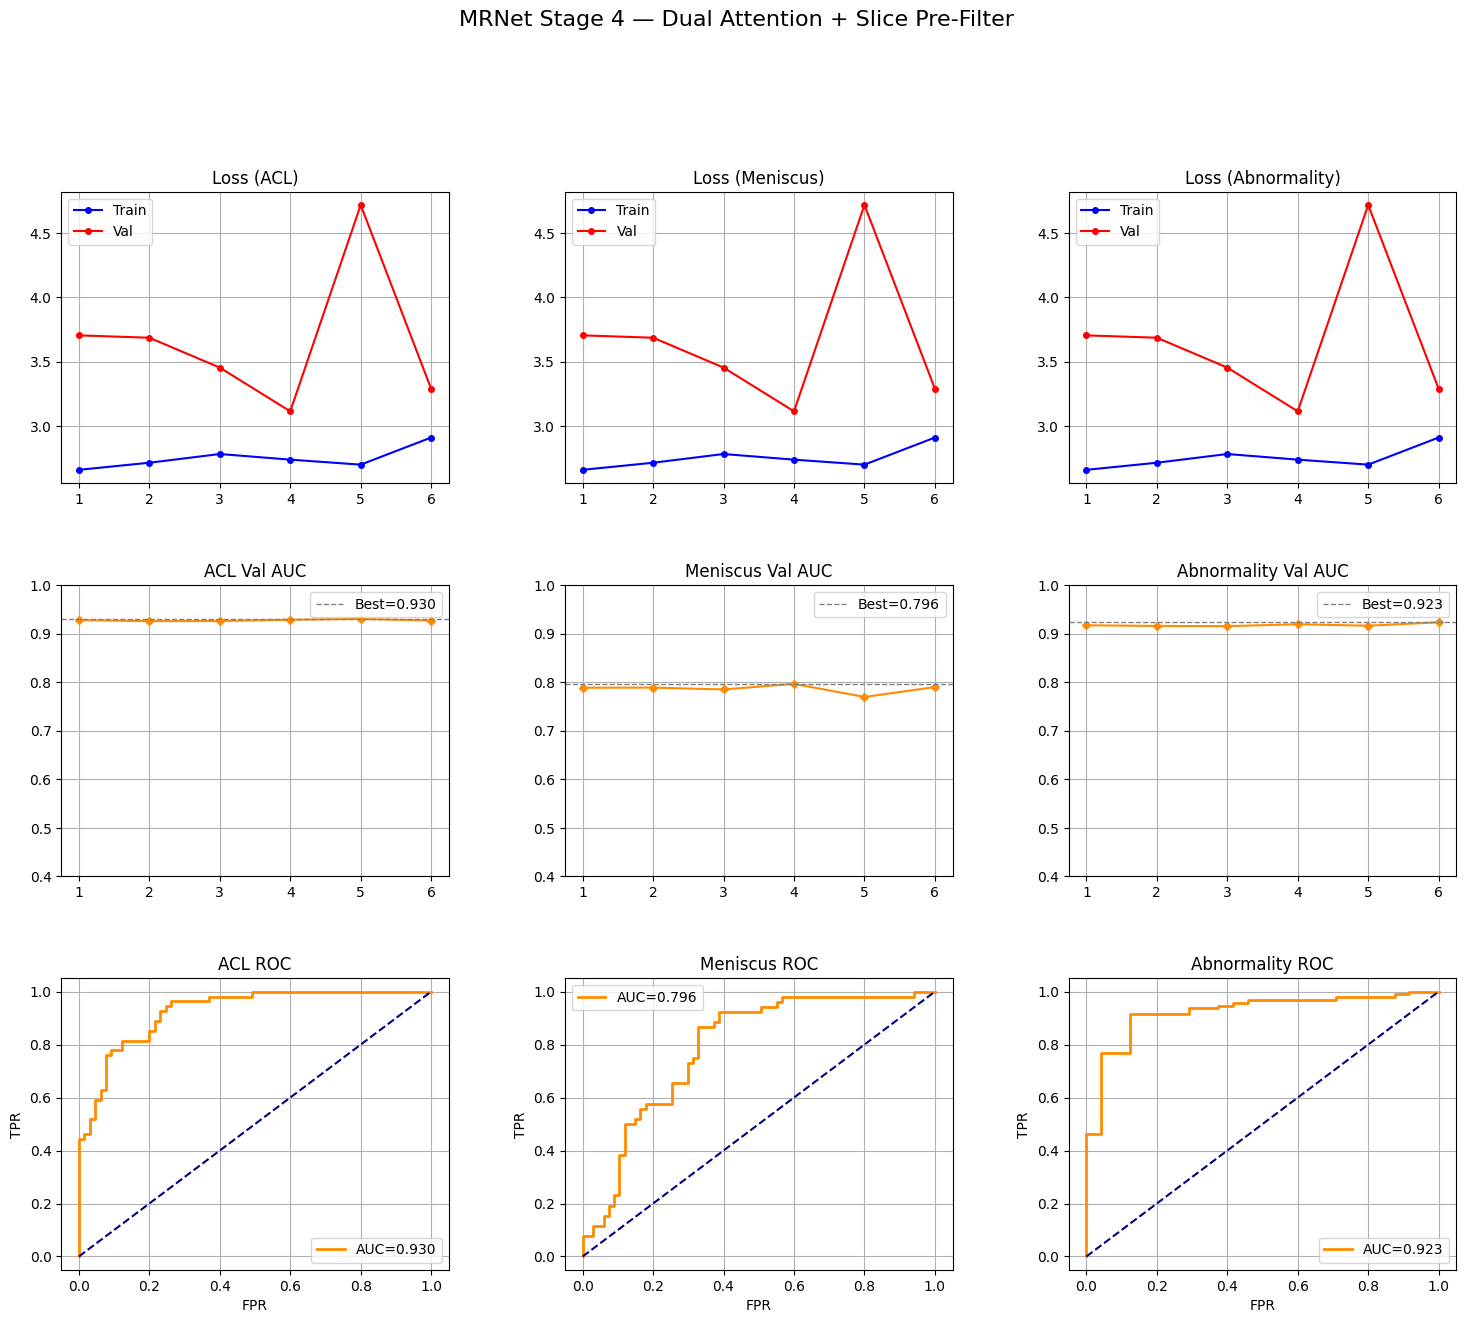

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.3)
ep = range(1, len(history['train_loss']) + 1)

for i, (key, name) in enumerate(zip(task_keys, task_names)):
    # Loss
    axes[0, i].plot(ep, history['train_loss'], 'b-o', ms=4, label='Train')
    axes[0, i].plot(ep, history['val_loss'],   'r-o', ms=4, label='Val')
    axes[0, i].set_title(f'Loss ({name})')
    axes[0, i].legend(); axes[0, i].grid(True)

    # AUC
    axes[1, i].plot(ep, history[f'val_{key}_auc'], 'darkorange', marker='D', ms=4)
    axes[1, i].axhline(max(history[f'val_{key}_auc']), color='grey',
                        linestyle='--', lw=1,
                        label=f"Best={max(history[f'val_{key}_auc']):.3f}")
    axes[1, i].set_title(f'{name} Val AUC')
    axes[1, i].set_ylim(0.4, 1.0)
    axes[1, i].legend(); axes[1, i].grid(True)

    # ROC
    fpr, tpr, _ = roc_curve(all_val_true[i], all_val_preds[i])
    axes[2, i].plot(fpr, tpr, 'darkorange', lw=2,
                    label=f"AUC={max(history[f'val_{key}_auc']):.3f}")
    axes[2, i].plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--')
    axes[2, i].set_title(f'{name} ROC'); axes[2, i].set_xlabel('FPR')
    axes[2, i].set_ylabel('TPR'); axes[2, i].legend(); axes[2, i].grid(True)

plt.suptitle('MRNet Stage 4 — Dual Attention + Slice Pre-Filter', fontsize=16, y=1.01)
plt.savefig('/content/drive/MyDrive/MLII Final/stage3_results.png',
            dpi=120, bbox_inches='tight')
plt.show()


# TEST ON MY MRI

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def view_mri_slice(npy_file, slice_index=None):
    # Load the 3D volume
    volume = np.load(npy_file)
    print(f"Volume shape: {volume.shape}")

    # If no slice_index provided, pick the middle one
    if slice_index is None:
        slice_index = volume.shape[0] // 2

    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(volume[slice_index, :, :], cmap='gray')
    plt.title(f"Slice {slice_index} from {npy_file}")
    plt.axis('off')
    plt.show()


Volume shape: (60, 512, 512)


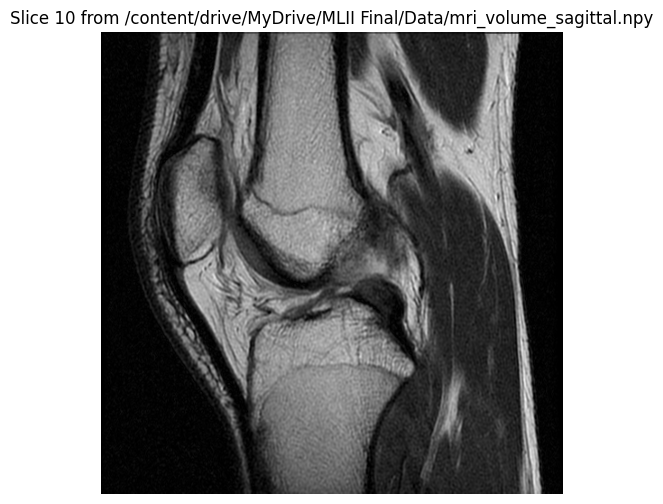

In [20]:
view_mri_slice('/content/drive/MyDrive/MLII Final/Data/mri_volume_sagittal.npy', 10)

Volume shape: (30, 512, 512)


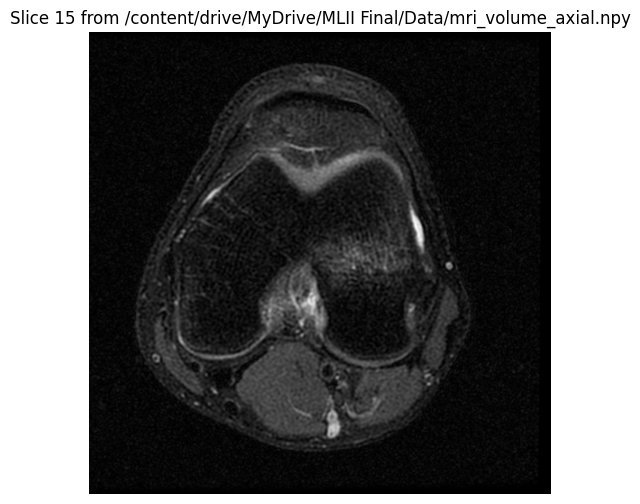

In [21]:
view_mri_slice('/content/drive/MyDrive/MLII Final/Data/mri_volume_axial.npy', 15)

Volume shape: (40, 512, 512)


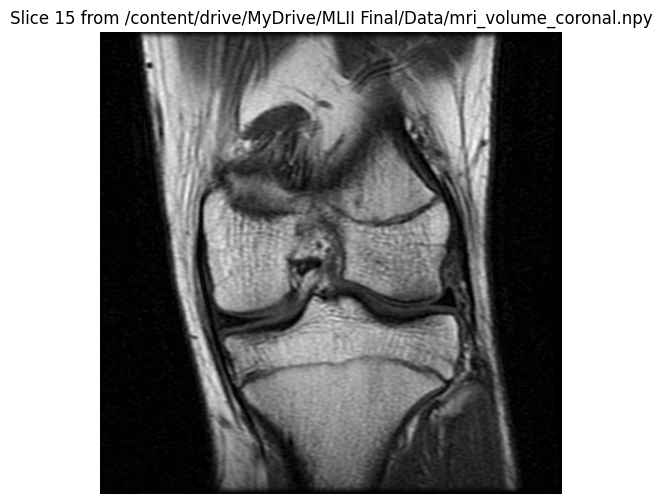

In [23]:
view_mri_slice('/content/drive/MyDrive/MLII Final/Data/mri_volume_coronal.npy', 15)

In [15]:
# ─── Inference on a single MRI exam ───────────────────────────────────────────
import torchvision.transforms as T

MAX_SLICES = 40  # must match training

_infer_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

def load_volume_for_inference(path, max_slices=MAX_SLICES):
    vol = np.load(path).astype(np.float32)
    v_min, v_max = vol.min(), vol.max()
    if v_max - v_min > 1e-6:
        vol = (vol - v_min) / (v_max - v_min) * 255.0
    vol = vol.astype(np.uint8)

    s = vol.shape[0]
    n_real = min(s, max_slices)

    if s > max_slices:
        start = (s - max_slices) // 2
        vol   = vol[start : start + max_slices]
        s     = max_slices

    slices = [_infer_transform(np.stack([vol[i]] * 3, axis=-1)) for i in range(s)]

    if s < max_slices:
        slices += [torch.zeros_like(slices[0])] * (max_slices - s)

    mask = torch.zeros(max_slices, dtype=torch.bool)
    mask[n_real:] = True

    return torch.stack(slices).unsqueeze(0), mask.unsqueeze(0)  # (1,S,3,H,W), (1,S)


# ── Load model from checkpoint ────────────────────────────────────────────────
INFER_PATH = '/content/drive/MyDrive/MLII Final/best_mrnet_stage4.pth'

infer_model = MRNetDualAttn(
    top_k=TOP_K_SLICES, d_fusion=D_FUSION,
    reduction=ATTN_REDUCTION, spatial_kernel=SPATIAL_KERNEL,
).to(DEVICE)

ckpt = torch.load(INFER_PATH, map_location=DEVICE, weights_only=False)
infer_model.load_state_dict(ckpt['model_state_dict'])
infer_model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}  best_avg_auc={ckpt['auc']:.4f}")




Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Loaded checkpoint — epoch 17  best_avg_auc=0.8814


In [17]:

# ── Run inference ─────────────────────────────────────────────────────────────
with torch.no_grad():
    ax,  mask_ax  = load_volume_for_inference('/content/drive/MyDrive/MLII Final/Data/mri_volume_axial.npy')
    cor, mask_cor = load_volume_for_inference('/content/drive/MyDrive/MLII Final/Data/mri_volume_coronal.npy')
    sag, mask_sag = load_volume_for_inference('/content/drive/MyDrive/MLII Final/Data/mri_volume_sagittal.npy')

    ax,  cor,  sag  = ax.to(DEVICE),  cor.to(DEVICE),  sag.to(DEVICE)
    mask_ax  = mask_ax.to(DEVICE)
    mask_cor = mask_cor.to(DEVICE)
    mask_sag = mask_sag.to(DEVICE)

    acl_logit, men_logit, abn_logit = infer_model(ax, cor, sag, mask_ax, mask_cor, mask_sag)

probs = {
    'ACL':         torch.sigmoid(acl_logit).item(),
    'Meniscus':    torch.sigmoid(men_logit).item(),
    'Abnormality': torch.sigmoid(abn_logit).item(),
}

print(f"\n{'═'*45}")
print(f"  Yuta's MRI predictions")
print(f"{'─'*45}")
THRESHOLD = 0.5
for task, p in probs.items():
    bar = '█' * int(p * 30) + '░' * (30 - int(p * 30))
    flag = '⚠  POSITIVE' if p >= THRESHOLD else '   negative'
    print(f"  {task:12s}  {bar}  {p:.3f}  {flag}")
print(f"{'═'*45}")


═════════════════════════════════════════════
  Yuta's MRI predictions
─────────────────────────────────────────────
  ACL           █████████████████████░░░░░░░░░  0.723  ⚠  POSITIVE
  Meniscus      █████████████░░░░░░░░░░░░░░░░░  0.460     negative
  Abnormality   ███████████████████████░░░░░░░  0.787  ⚠  POSITIVE
═════════════════════════════════════════════
